# End-to-end BPAM-4 with a fitted digital surrogate

Derived from `bpam_complex.ipynb`: same TX 10-16-2 and RX 12-64-128-32-2,
DAC 6 bits, ADC 8/6/5 bits, 2 samples/symbol, and BER versus OSNR.
The TX and RX are jointly trained through a **frozen, fitted hybrid digital surrogate**.
The three channel FIR responses are learned from simulator I/O; the MZM law,
dispersion, loss and ASE law remain known. This is not the laboratory digital surrogate.

`FORCE_RETRAIN=False` loads compatible checkpoints, training only missing models.
`FORCE_RETRAIN=True` retrains the digital surrogate once, then every TX/RX pair.
The digital surrogate is shared across ADC settings because the ADC is in the receiver,
outside its drive-to-photocurrent boundary. Its weights remain frozen during E2E training.

The independent ADC6, seed0 pilot passed simulator-transfer validation: at OSNR
17 dB the digital surrogate-trained pair produced 1608 errors out of 7,995,392 bits on
both the digital surrogate and the original simulator. This is a single-seed, matched-model
test, not an experimental-channel validation or a claim of equal training outcomes.

BER and eyes below are evaluated through the fitted digital surrogate. Results and
checkpoints go only to `results/bpam_surrogate/`; no paper files are overwritten.
OSNR = Eb/N0 + 2.05 dB, as in the original notebook.


Workspace layout: this notebook writes to `results/bpam_surrogate/`. Published artifacts remain separately in `results/paper/`.


## 1. Setup and knobs

In [17]:
# Resolve paths independently of the notebook's working directory.
from pathlib import Path
import os
import sys
PROJECT_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
                    if (p / "functions" / "config.py").is_file())
sys.path.insert(0, str(PROJECT_ROOT / "functions"))
os.chdir(PROJECT_ROOT)

import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import sys
import json
import hashlib
from pathlib import Path
sys.path.insert(0, "functions")

%load_ext autoreload
%autoreload 2

import numpy as np
import torch
import matplotlib.pyplot as plt

from scenarios import asfand_complex, checkpoint_name, OSNR_OFFSET_DB, TRAIN_EBN0_DB, TRAIN_STEPS
from train import train, evaluate

%matplotlib inline
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

# ---------------- knobs ----------------
ADC_BITS   = [8, 6, 5]        # the family of the paper figure
PRECODE    = False            # differential precoder at the DPD input (A/B: False is better)
TX_PULSE   = None             # None = scenario default (freq-rect 20 GHz), the PUBLISHED curve.
NRZ_RECT   = 1.0              # "nrz" + NRZ_RECT = NRZ pulse cascaded with the 20 GHz rect.
                              # h(T/2): NRZ 0.61 -> cascade 0.45 -> freq-rect alone 0.00. The bare
                              # freq-rect nulls the T/2 cross-term that carries the differential
                              # sign, so a bipolar constellation is undecodable with it -- but this
                              # E2E is UNIPOLAR anyway and the freq-rect serves it better: measured
                              # 1.80e-4 (freq-rect) vs 3.39e-4 (NRZ cascade) at OSNR 17, N_ADC=6.
                              # The NRZ cascade belongs to bpam_warmstart, where the signal IS bipolar.
SEED       = 0
NUM_STEPS  = TRAIN_STEPS      # 100k
FORCE_RETRAIN = False

OSNR_GRID = list(range(11, 21))
EBN0_FOR_OSNR = [o - OSNR_OFFSET_DB for o in OSNR_GRID]

def num_symbols(ebn0_db):
    return 4_000_000 if ebn0_db <= 14.0 else 16_000_000

print(asfand_complex(adc_bits=6, precode=PRECODE, rx="asfand").summary())

from simulated_surrogate import prepare_digital_surrogate, frozen_channel, file_digest

WORK = Path("results") / "bpam_surrogate"
WORK.mkdir(parents=True, exist_ok=True)

def make_config(adc_bits):
    cfg = asfand_complex(adc_bits=adc_bits, precode=PRECODE, rx="asfand")
    if TX_PULSE is not None:
        cfg.tx_filter = TX_PULSE
        cfg.nrz_rect_cutoff_ratio = NRZ_RECT
        cfg._compute_derived()
        cfg.set_modulation_format("bpam-4")
    return cfg


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
device: cuda
symbol rate          : 20 GBaud
bit rate             : 40 Gb/s  (bipolar PAM-4/DD (differential sign, 2 rx sps))
sim sample rate      : 40 GHz  (2 sps, Nyquist 20 GHz)
rx sample rate       : 40 GHz  (2 sps)
photodiode bandwidth : 25 GHz  (representable: False)
modulator            : mzm  (MZM 30 GHz, 1 segments)
pulse shape          : freq-rect 20 GHz (brickwall)
equalizer            : DPD (TX) + FFE (RX), trained jointly
wavelength band      : cband  (1550 nm, beta2 -21.7 ps^2/km, L 10.238 km, beta2*L -222.2 ps^2)
noise regime         : ase
optical filter       : wss, Bo 37 GHz


## 2. Fit or load the digital surrogate, then train or load TX/RX

The digital surrogate starts from identity FIRs and is fitted on independent Gaussian-drive
blocks with noiseless simulator targets (5000 Adam steps). Validation selects the
checkpoint; separate test blocks check waveform error, noisy propagation and input
gradients. A failed check stops the notebook before TX/RX training.

The same `FORCE_RETRAIN` controls both stages. TX/RX checkpoints are tied to the
digital surrogate weights, configuration, training settings and DSP source code.


In [18]:
from transmitter import Transmitter
from receiver import Receiver

# One fitted channel for all ADC resolutions. This is outside the ADC loop.
digital_surrogate_info = prepare_digital_surrogate(
    make_config(6), WORK / "surrogate", device, force_retrain=FORCE_RETRAIN)
print("Digital surrogate test NMSE:", digital_surrogate_info["report"]["test_nmse"])

def load_or_train(adc_bits, force_retrain=False):
    cfg = make_config(adc_bits)
    cfg.channel_source = "surrogate"
    cfg.surrogate_checkpoint = digital_surrogate_info["checkpoint"]
    metadata = {
        "config": vars(cfg), "surrogate_sha256": digital_surrogate_info["sha256"],
        "seed": SEED, "steps": NUM_STEPS, "train_ebn0_db": TRAIN_EBN0_DB,
        "source_sha256": {name: file_digest(Path("functions") / f"{name}.py")
                          for name in ("train", "transmitter", "receiver", "utils", "pulse_shaping")},
    }
    key = hashlib.sha256(json.dumps(metadata, sort_keys=True).encode()).hexdigest()[:16]
    path = WORK / "checkpoints" / f"e2e_adc{adc_bits}_{key}.pt"
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.manual_seed(SEED)
    np.random.seed(SEED)
    if path.exists() and not force_retrain:
        state = torch.load(path, map_location=device, weights_only=True)
        if state["metadata"] != metadata:
            raise RuntimeError("Incompatible TX/RX checkpoint; use FORCE_RETRAIN=True.")
        tx, rx = Transmitter(cfg).to(device), Receiver(cfg).to(device)
        ch = frozen_channel(cfg, cfg.surrogate_checkpoint, device)
        tx.load_state_dict(state["tx"])
        rx.load_state_dict(state["rx"])
        print(f"Loaded {path}")
    else:
        print(f"Training N_ADC={adc_bits} through the frozen digital surrogate ({NUM_STEPS} steps)")
        tx, ch, rx = train(cfg, device, num_steps=NUM_STEPS,
                           ebn0_range=(TRAIN_EBN0_DB, TRAIN_EBN0_DB))
        temporary = path.with_suffix(".tmp")
        torch.save({"tx": tx.state_dict(), "rx": rx.state_dict(), "metadata": metadata}, temporary)
        temporary.replace(path)
        print(f"Saved {path}")
    assert all(not p.requires_grad and p.grad is None for p in ch.parameters())
    tx.eval()
    ch.eval()
    rx.eval()
    return tx, ch, rx, cfg

nets = {}
for adc in ADC_BITS:
    nets[adc] = load_or_train(adc, force_retrain=FORCE_RETRAIN)
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
print("Ready:", list(nets))


Loaded validated digital surrogate: results\bpam_surrogate\surrogate\1a75b1d37b8e9394\surrogate.pt
Digital surrogate test NMSE: 1.5954971099415673e-12
Loaded results\bpam_surrogate\checkpoints\e2e_adc8_4d30585b1605e2d2.pt
Loaded results\bpam_surrogate\checkpoints\e2e_adc6_c60a3c4d8a92cbb9.pt
Loaded results\bpam_surrogate\checkpoints\e2e_adc5_67ff94c0040a9cc5.pt
Ready: [8, 6, 5]


## 3. Measure BER versus OSNR

In [19]:
results = {"osnr": {}}

for adc, (tx, ch, rx, cfg) in nets.items():
    results["osnr"][adc] = [evaluate(tx, ch, rx, cfg, [e], num_symbols(e), device)[0]
                            for e in EBN0_FOR_OSNR]
    torch.cuda.empty_cache()
    print(f"N_ADC={adc}  done")

print("\nOSNR [dB]  " + " ".join(f"{o:>9d}" for o in OSNR_GRID))
for adc in ADC_BITS:
    print(f"N_ADC={adc}   " + " ".join(f"{b:9.2e}" for b in results["osnr"][adc]))

Eb/N0   8.9 dB   BER 3.910e-02   (shift 0)
Eb/N0   9.9 dB   BER 2.217e-02   (shift 0)
Eb/N0  10.9 dB   BER 1.117e-02   (shift 0)
Eb/N0  11.9 dB   BER 4.842e-03   (shift 0)
Eb/N0  12.9 dB   BER 1.879e-03   (shift 0)
Eb/N0  13.9 dB   BER 6.130e-04   (shift 0)
Eb/N0  14.9 dB   BER 1.730e-04   (shift 0)
Eb/N0  15.9 dB   BER 4.438e-05   (shift 0)
Eb/N0  16.9 dB   BER 9.438e-06   (shift 0)
Eb/N0  17.9 dB   BER 1.844e-06   (shift 0)
N_ADC=8  done
Eb/N0   8.9 dB   BER 4.076e-02   (shift 0)
Eb/N0   9.9 dB   BER 2.310e-02   (shift 0)
Eb/N0  10.9 dB   BER 1.188e-02   (shift 0)
Eb/N0  11.9 dB   BER 5.404e-03   (shift 0)
Eb/N0  12.9 dB   BER 2.112e-03   (shift 0)
Eb/N0  13.9 dB   BER 7.170e-04   (shift 0)
Eb/N0  14.9 dB   BER 2.138e-04   (shift 0)
Eb/N0  15.9 dB   BER 5.688e-05   (shift 0)
Eb/N0  16.9 dB   BER 1.300e-05   (shift 0)
Eb/N0  17.9 dB   BER 2.844e-06   (shift 0)
N_ADC=6  done
Eb/N0   8.9 dB   BER 4.407e-02   (shift 0)
Eb/N0   9.9 dB   BER 2.631e-02   (shift 0)
Eb/N0  10.9 dB   BER 1.394

## 4. Load the historical BPAM + adaptive-equalizer reference

This is the same MATLAB reference file used by `bpam_complex.ipynb`, not a new
digital surrogate-transfer control. It is read only and is not regenerated here.


In [20]:
REF = os.path.join("results", "paper", "bpam_ae_reference_osnrgrid.txt")
baseline = {}
for line in open(REF):
    if line.startswith("#") or not line.strip():
        continue
    p = line.split()
    nb = int(p[0])
    baseline.setdefault(nb, {"ebn0": [], "osnr": [], "ber": []})
    baseline[nb]["ebn0"].append(float(p[2]))
    baseline[nb]["osnr"].append(float(p[3]))
    baseline[nb]["ber"].append(float(p[4]))
print("baseline loaded for N_ADC:", sorted(baseline))

baseline loaded for N_ADC: [5, 6, 8]


## 5. Column files (the format shared with the co-authors)

In [21]:
OUT = str(WORK)
os.makedirs(OUT, exist_ok=True)

HEADER = (
    "# End-to-end autoencoder trained and tested through a fitted hybrid digital surrogate, C-band 10.238 km, MZM ER 30 dB, TX 20 GHz rect, WSS optical filter,\n"
    "# RX 10 GHz Gaussian, N_DAC = 6, 2 samples/symbol. RX-DSP = fully connected 64-128-32 with\n"
    "# sigmoid output, context window 6 symbols (12 samples); TX-DSP = fully connected 16.\n"
    "# OSNR = Eb/N0 + 2.05 dB (signal 1 pol, ASE 2 pol, Bref 12.5 GHz).\n"
    "\n"
    "# columns:\n")

def save(axis, grid, axis_name, fname):
    heads = [f"{axis_name}[dB]"] + [f"E2E_adc{nb}" for nb in ADC_BITS] + \
            [f"BPAM_AE_adc{nb}" for nb in ADC_BITS]
    cols = [results[axis][nb] for nb in ADC_BITS] + [[dict(zip(baseline[nb]["osnr"], baseline[nb]["ber"]))[float(x)] for x in grid] for nb in ADC_BITS]
    with open(os.path.join(OUT, fname), "w") as f:
        f.write(HEADER)
        f.write("# " + "  ".join(f"{h:>16s}" for h in heads)[2:] + "\n\n")
        for i, x in enumerate(grid):
            f.write(f"{x:8.2f}  " + "  ".join(f"{c[i]:16.4e}" for c in cols) + "\n")
    print("written", os.path.join(OUT, fname))

save("osnr", OSNR_GRID, "OSNR", "bpam_surrogate.txt")

written results\bpam_surrogate\bpam_surrogate.txt


## 6. Figures

Solid: end-to-end. Dashed: BPAM + adaptive equalizer, same `N_ADC` (same color).

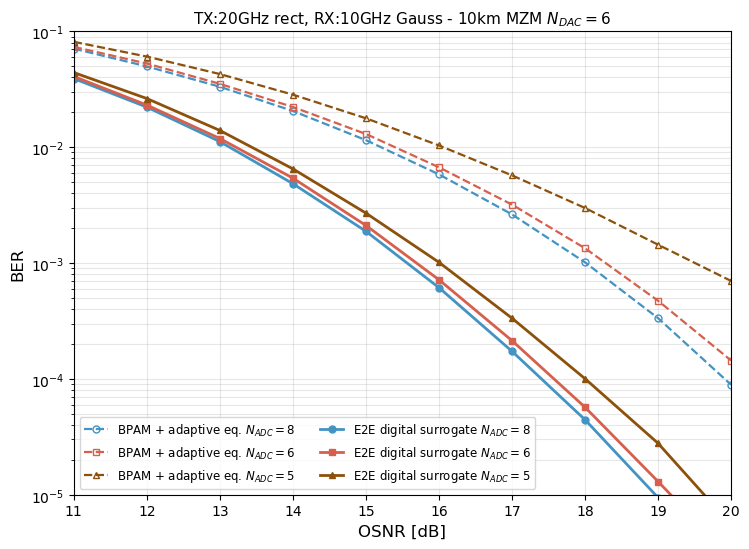

In [22]:

STYLE = {8: ("o", "#4393c3"), 6: ("s", "#d6604d"), 5: ("^", "#8c510a")}

def figure(axis, grid, xlabel, bkey, fname):
    fig, ax = plt.subplots(figsize=(7.6, 5.6))
    for nb in ADC_BITS:
        mk, c = STYLE[nb]
        pts = [(x, y) for x, y in zip(baseline[nb][bkey], baseline[nb]["ber"]) if y > 0]
        ax.semilogy([p[0] for p in pts], [p[1] for p in pts], "--" + mk, color=c, lw=1.6,
                    ms=5, mfc="none", label=f"BPAM + adaptive eq. $N_{{ADC}}={nb}$")
    for nb in ADC_BITS:
        mk, c = STYLE[nb]
        ax.semilogy(grid, np.maximum(results[axis][nb], 1e-7), "-" + mk, color=c, lw=2,
                    ms=5, label=f"E2E digital surrogate $N_{{ADC}}={nb}$")
    ax.set_xlim(min(grid), max(grid)); ax.set_ylim(1e-5, 1e-1); ax.set_xticks(grid)
    ax.set_xlabel(xlabel, fontsize=12); ax.set_ylabel("BER", fontsize=12)
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(fontsize=8.5, loc="lower left", ncol=2)
    ax.set_title("TX:20GHz rect, RX:10GHz Gauss - 10km MZM $N_{DAC}=6$", fontsize=11)
    fig.tight_layout()
    fig.savefig(os.path.join(OUT, fname + ".pdf"), bbox_inches="tight")
    fig.savefig(os.path.join(OUT, fname + ".png"), bbox_inches="tight", dpi=150)
    plt.show()

figure("osnr", OSNR_GRID, "OSNR [dB]", "osnr", "bpam_surrogate")

## 6b. Noiseless photocurrent eye through the fitted digital surrogate

The waveform is taken after the digital surrogate photodetector response and the RX
Gaussian filter, before the ADC. No matched filter is applied. Interpolation
is for display only; it does not turn the 2-sps simulation into a high-rate simulation.


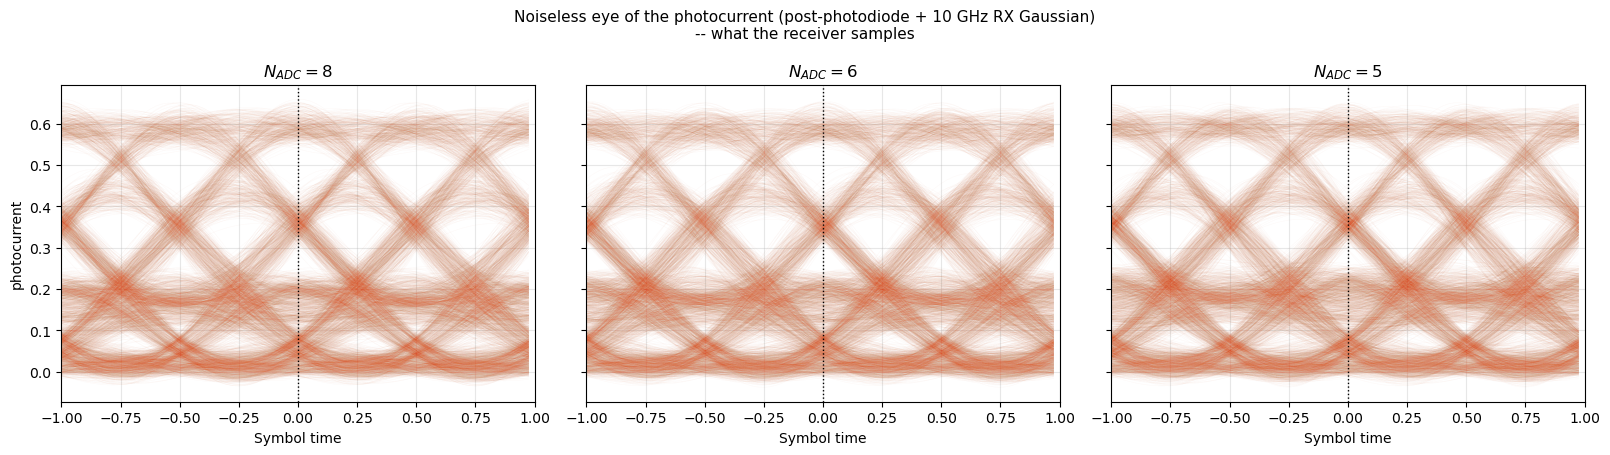

In [23]:
import torch.nn.functional as F
from scipy.signal import resample_poly
from train import random_bits
from transmitter import bits_to_symbols
from utils import decision_phase_by_separation

def draw_eye(ax, signal, samples_per_symbol, phase, title, fine_sps=40, skip=100, num_symbols=4000):
    fine = resample_poly(signal[:(skip + num_symbols + 8) * samples_per_symbol],
                         fine_sps, samples_per_symbol)
    offset = int(round(phase * fine_sps / samples_per_symbol))
    centers = (skip + np.arange(num_symbols)) * fine_sps + offset
    keep = (centers - fine_sps >= 0) & (centers + fine_sps < len(fine))
    centers = centers[keep]
    window = np.arange(-fine_sps, fine_sps)[:, None] + centers[None, :]
    ax.plot(np.arange(-fine_sps, fine_sps) / fine_sps, fine[window],
            color=(0.85, 0.33, 0.10, 0.03), linewidth=0.4)
    ax.axvline(0, color="k", linestyle=":", linewidth=1)
    ax.set_xlim(-1, 1)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel("Symbol time")
    ax.set_title(title)

fig, axes = plt.subplots(1, len(nets), figsize=(5.4 * len(nets), 4.6), sharey=True)
axes = np.atleast_1d(axes)
for ax, (adc, (tx, ch, rx, cfg)) in zip(axes, nets.items()):
    sps = cfg.samples_per_symbol_sim
    torch.manual_seed(7)
    with torch.no_grad():
        bits = random_bits(cfg.bits_per_symbol, 6000, device)
        symbols = bits_to_symbols(bits, cfg.bits_per_symbol).cpu().numpy()
        p = ch(tx(bits), ase_ebn0_db=None)                    # noiseless photocurrent (post-photodiode)
        if rx.rx_gauss is not None:                           # 10 GHz RX Gaussian (the RX electrical filter)
            p = F.conv1d(p.view(1, 1, -1), rx.rx_gauss, padding=rx.rx_gauss.shape[-1] // 2).view(-1)
        photocurrent = p.cpu().numpy()
    phase, _ = decision_phase_by_separation(photocurrent, sps, symbols, skip=100)
    title = "ideal ADC" if adc is None else f"$N_{{ADC}}={adc}$"
    draw_eye(ax, photocurrent, sps, phase, title)
axes[0].set_ylabel("photocurrent")
fig.suptitle("Noiseless eye of the photocurrent (post-photodiode + 10 GHz RX Gaussian)\n"
             "-- what the receiver samples", fontsize=11)
fig.tight_layout()
fig.savefig(os.path.join(OUT, "bpam_surrogate_eyes.png"), dpi=150, bbox_inches="tight")
plt.show()

## 7. Horizontal gain vs the reference, at equal ADC resolution

In [24]:
def crossing(x, y, target):
    x = np.asarray(x, float)
    ly = np.log10(np.maximum(np.asarray(y, float), 1e-12))
    lt = np.log10(target)
    for i in range(len(x) - 1):
        if (ly[i] - lt) * (ly[i + 1] - lt) <= 0:
            return x[i] + (x[i + 1] - x[i]) * (lt - ly[i]) / (ly[i + 1] - ly[i])
    return np.nan

for target in (1e-2, 1e-3):
    print(f"\nBER = {target:.0e}   (OSNR axis)")
    for nb in ADC_BITS:
        bx = [x for x, y in zip(baseline[nb]["osnr"], baseline[nb]["ber"]) if y > 0]
        by = [y for y in baseline[nb]["ber"] if y > 0]
        gb = crossing(bx, by, target)
        ge = crossing(OSNR_GRID, results["osnr"][nb], target)
        print(f"  N_ADC={nb}:  baseline @ {gb:5.2f} dB   E2E @ {ge:5.2f} dB"
              f"   ->  gain {gb - ge:+.2f} dB")


BER = 1e-02   (OSNR axis)
  N_ADC=8:  baseline @ 15.21 dB   E2E @ 13.13 dB   ->  gain +2.07 dB
  N_ADC=6:  baseline @ 15.40 dB   E2E @ 13.22 dB   ->  gain +2.18 dB
  N_ADC=5:  baseline @ 16.06 dB   E2E @ 13.44 dB   ->  gain +2.62 dB

BER = 1e-03   (OSNR axis)
  N_ADC=8:  baseline @ 18.01 dB   E2E @ 15.56 dB   ->  gain +2.45 dB
  N_ADC=6:  baseline @ 18.28 dB   E2E @ 15.69 dB   ->  gain +2.59 dB
  N_ADC=5:  baseline @ 19.51 dB   E2E @ 16.01 dB   ->  gain +3.49 dB
